# GDD prebase

For context, see the description in the analogous notebook `GDD_FRc_Kuramoto.ipynb`

This notebook computes, for the prebase graphs:
1. Forman–Ricci curvature for each graph.
2. A single global positive linear transform of the curvatures.
3. Positive edge weights derived from the transformed curvatures.
4. Graph diffusion distance (GDD) between every pair of transformed graphs.
5. A heatmap of the resulting all-by-all distance matrix.

It also includes a 3-graph test to verify all works before running the pipeline on the whole dataset. 


## Notebook settings

In [1]:
verbose = True
show_weight_distributions = True

## Imports

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from pathlib import Path

from hyphi.io_brainhack import load_all_prebase_adjacencies

from hyphi.modeling.transform_curvature import (
    as_1d_float_array,
    fit_global_positive_linear_transform,
    transform_curvature_collection,
    check_all_positive,
    attach_edge_weights_to_graph,
)

from hyphi.modeling.GDD_FRc_helpers import (
    compute_global_curvature_stats,
    compute_frc_bundles_from_adjacencies,
    compute_pairwise_gdd_matrix,
)

from hyphi.visualization.GDD_FRc_visualization import (
    plot_weight_distributions_by_matrix,
    plot_gdd_heatmap,
)


***********************************************************************************************
***********************************************************************************************

                                             HyPhi                                             

***********************************************************************************************
***********************************************************************************************

Current working dir:	C:\Users\Lenovo\Desktop\Brainhack26_HyPhi\HyPhi\code\notebooks
New working dir: 'C:\Users\Lenovo\Desktop\Brainhack26_HyPhi'



## Paths and parameters

In [3]:
prebase_base_dir = Path("HyPhi") / "data" / "prebase"
prebase_suffix = "_prebase_graph.pkl"

pilot_indices = [1, 2, 3]
full_indices = list(range(1, 30))

weight_key = "weight"
symmetrize = False
frc_method = "1d"
weight_attr = "positive_weight"

## Helpers

In [4]:
def run_prebase_pipeline(
    indices,
    base_dir=Path("HyPhi") / "data" / "prebase",
    suffix="_prebase_graph.pkl",
    weight_key="weight",
    symmetrize=False,
    frc_method="1d",
    transform_flip_sign=True,
    transform_rescale=None,
    weight_attr="positive_weight",
    show_weight_distributions=True,
    bins="fd",
    heatmap_figsize=(8, 6),
    heatmap_cmap="viridis",
    verbose=False,
):
    """
    Beware, this function is a bit of a mess (but it works!) 
    
    End-to-end pipeline for prebase adjacency matrices:
    - load adjacency matrices
    - compute FRc
    - fit an FRc transformation model + transform curvatures into positive weights
    - attach transformed weights to graphs
    - compute GDD between all loaded graphs
    - optionally plot transformed-weight histograms and GDD heatmap

    Returns a dictionary of results. 
    """
    loaded = load_all_prebase_adjacencies(
        indices=indices,
        base_dir=base_dir,
        suffix=suffix,
        weight_key=weight_key,
        symmetrize=symmetrize,
        verbose=verbose,
    )
    
    results = compute_frc_bundles_from_adjacencies(
        loaded["adjacencies"],
        method=frc_method,
        paths=loaded["paths"],
        verbose=verbose,
    )

    paths = {k: v["path"] for k, v in results.items()}
    adjacencies = {k: v["adjacency"] for k, v in results.items()}
    graphs = {k: v["graph"] for k, v in results.items()}
    frc_graphs = {k: v["graph_frc"] for k, v in results.items()}
    edge_curvatures = {k: v["edge_curvatures"] for k, v in results.items()}
    curvatures = {k: v["curvatures"] for k, v in results.items()}

    global_curvature_stats = compute_global_curvature_stats(curvatures)

    global_linear_params = fit_global_positive_linear_transform(
        curvatures,
        flip_sign=transform_flip_sign,
        rescale=transform_rescale,
    )

    positive_curvatures = transform_curvature_collection(
        curvatures,
        global_linear_params,
    )

    positive_edge_weights = transform_curvature_collection(
        edge_curvatures,
        global_linear_params,
    )

    for k in results:
        results[k]["positive_weight_params"] = global_linear_params
        results[k]["positive_curvatures"] = positive_curvatures[k]
        results[k]["positive_edge_weights"] = positive_edge_weights[k]

    positive_weight_graphs = {
        k: attach_edge_weights_to_graph(
            frc_graphs[k],
            positive_edge_weights[k],
            attr_name=weight_attr,
        )
        for k in frc_graphs
    }

    positivity_summary = check_all_positive(positive_curvatures)
    if verbose:
        print(positivity_summary)

    if show_weight_distributions:
        fig = plot_weight_distributions_by_matrix(
            positive_curvatures,
            bins=bins,
            ncols=3,
            main_title="Positive transformed weight distributions for prebase graphs",
        )
        plt.show()

    matrix_indices, pairwise_gdd, laplacians = compute_pairwise_gdd_matrix(
        positive_weight_graphs,
        weight_attr=weight_attr,
        verbose=verbose,
    )

    labels = [f"{idx:02d}" for idx in matrix_indices]
    fig, ax = plot_gdd_heatmap(
        pairwise_gdd,
        labels=labels,
        figsize=heatmap_figsize,
        cmap=heatmap_cmap,
        title="Pairwise GDD heatmap for experimental graphs.",
    )
    # fig.savefig("prebase_GDD_heatmap.png")

    if verbose:
        plt.show()

    if not np.allclose(pairwise_gdd, pairwise_gdd.T):
        raise RuntimeError("Pairwise GDD matrix is not symmetric.")

    if not np.allclose(np.diag(pairwise_gdd), 0.0):
        raise RuntimeError("Pairwise GDD matrix diagonal is not zero.")

    return {
        "indices": matrix_indices,
        "labels": labels,
        "paths": paths,
        "adjacencies": adjacencies,
        "graphs": graphs,
        "frc_graphs": frc_graphs,
        "edge_curvatures": edge_curvatures,
        "curvatures": curvatures,
        "global_curvature_stats": global_curvature_stats,
        "global_linear_params": global_linear_params,
        "positive_curvatures": positive_curvatures,
        "positive_edge_weights": positive_edge_weights,
        "positive_weight_graphs": positive_weight_graphs,
        "positivity_summary": positivity_summary,
        "laplacians": laplacians,
        "pairwise_gdd": pairwise_gdd,
    }


## Test: run the procedure on 3 matrices

[1] loaded HyPhi\data\prebase\01_prebase_graph.pkl
   adjacency shape: (64, 64)
[2] loaded HyPhi\data\prebase\02_prebase_graph.pkl
   adjacency shape: (64, 64)
[3] loaded HyPhi\data\prebase\03_prebase_graph.pkl
   adjacency shape: (64, 64)
[1] computed FRC bundle
   path: HyPhi\data\prebase\01_prebase_graph.pkl
   adjacency shape: (64, 64)
   number of curvature values: 403
[2] computed FRC bundle
   path: HyPhi\data\prebase\02_prebase_graph.pkl
   adjacency shape: (64, 64)
   number of curvature values: 403
[3] computed FRC bundle
   path: HyPhi\data\prebase\03_prebase_graph.pkl
   adjacency shape: (64, 64)
   number of curvature values: 403
{1: {'min': 3.999719875802241, 'max': 64.0239483810847, 'all_positive': True}, 2: {'min': 9.99999860695766e-10, 'max': 59.022796363736276, 'all_positive': True}, 3: {'min': 9.99999860695766e-10, 'max': 50.22031617448602, 'all_positive': True}}


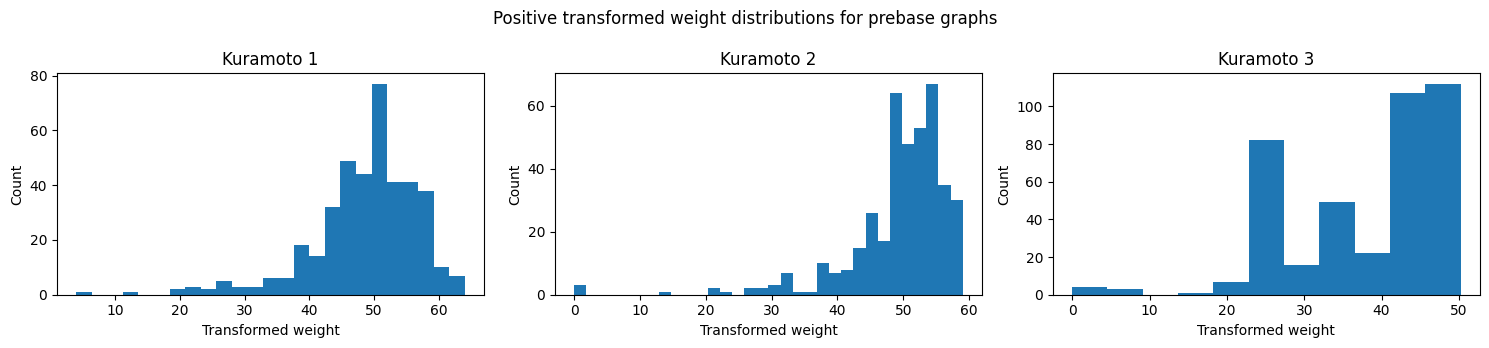

GDD(01, 02) = 5.772022109604314
GDD(01, 03) = 5.237532803595234
GDD(02, 03) = 5.0212127407493865


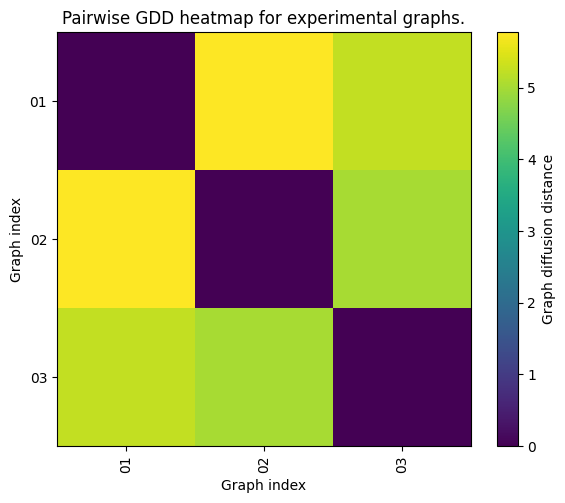

Pilot graph indices: ['01', '02', '03']

Pilot global transform parameters:
sign: -1.0
scale: 1.0
shift: 2.0000000009999996
raw_global_min: -62.0239483800847
raw_global_max: 1.9999999999999998
signed_global_min: -1.9999999999999998
signed_global_max: 62.0239483800847
transformed_global_min: 9.99999860695766e-10
transformed_global_max: 64.0239483810847

Pilot positivity check:
Prebase 01: min=3.99972, max=64.0239, all_positive=True
Prebase 02: min=1e-09, max=59.0228, all_positive=True
Prebase 03: min=1e-09, max=50.2203, all_positive=True

Pilot pairwise GDD matrix:
[[0.       5.772022 5.237533]
 [5.772022 0.       5.021213]
 [5.237533 5.021213 0.      ]]


In [5]:
pilot_output = run_prebase_pipeline(
    indices=pilot_indices,
    base_dir=prebase_base_dir,
    suffix=prebase_suffix,
    weight_key=weight_key,
    symmetrize=symmetrize,
    frc_method=frc_method,
    transform_flip_sign=True,
    transform_rescale=None,
    weight_attr=weight_attr,
    show_weight_distributions=show_weight_distributions,
    bins="fd",
    heatmap_figsize=(6, 5),
    heatmap_cmap="viridis",
    verbose=verbose,
)

if verbose:
    print("Pilot graph indices:", pilot_output["labels"])
    print("\nPilot global transform parameters:")
    for key, value in pilot_output["global_linear_params"].items():
        print(f"{key}: {value}")
    
    print("\nPilot positivity check:")
    for idx in pilot_output["indices"]:
        stats = pilot_output["positivity_summary"][idx]
        print(
            f"Prebase {idx:02d}: "
            f"min={stats['min']:.6g}, "
            f"max={stats['max']:.6g}, "
            f"all_positive={stats['all_positive']}"
        )
    
    print("\nPilot pairwise GDD matrix:")
    print(np.round(pilot_output["pairwise_gdd"], 6))


## Full run: all 29 prebase graphs

[1] loaded HyPhi\data\prebase\01_prebase_graph.pkl
   adjacency shape: (64, 64)
[2] loaded HyPhi\data\prebase\02_prebase_graph.pkl
   adjacency shape: (64, 64)
[3] loaded HyPhi\data\prebase\03_prebase_graph.pkl
   adjacency shape: (64, 64)
[4] loaded HyPhi\data\prebase\04_prebase_graph.pkl
   adjacency shape: (64, 64)
[5] loaded HyPhi\data\prebase\05_prebase_graph.pkl
   adjacency shape: (64, 64)
[6] loaded HyPhi\data\prebase\06_prebase_graph.pkl
   adjacency shape: (64, 64)
[7] loaded HyPhi\data\prebase\07_prebase_graph.pkl
   adjacency shape: (64, 64)
[8] loaded HyPhi\data\prebase\08_prebase_graph.pkl
   adjacency shape: (64, 64)
[9] loaded HyPhi\data\prebase\09_prebase_graph.pkl
   adjacency shape: (64, 64)
[10] loaded HyPhi\data\prebase\10_prebase_graph.pkl
   adjacency shape: (64, 64)
[11] loaded HyPhi\data\prebase\11_prebase_graph.pkl
   adjacency shape: (64, 64)
[12] loaded HyPhi\data\prebase\12_prebase_graph.pkl
   adjacency shape: (64, 64)
[13] loaded HyPhi\data\prebase\13_pre

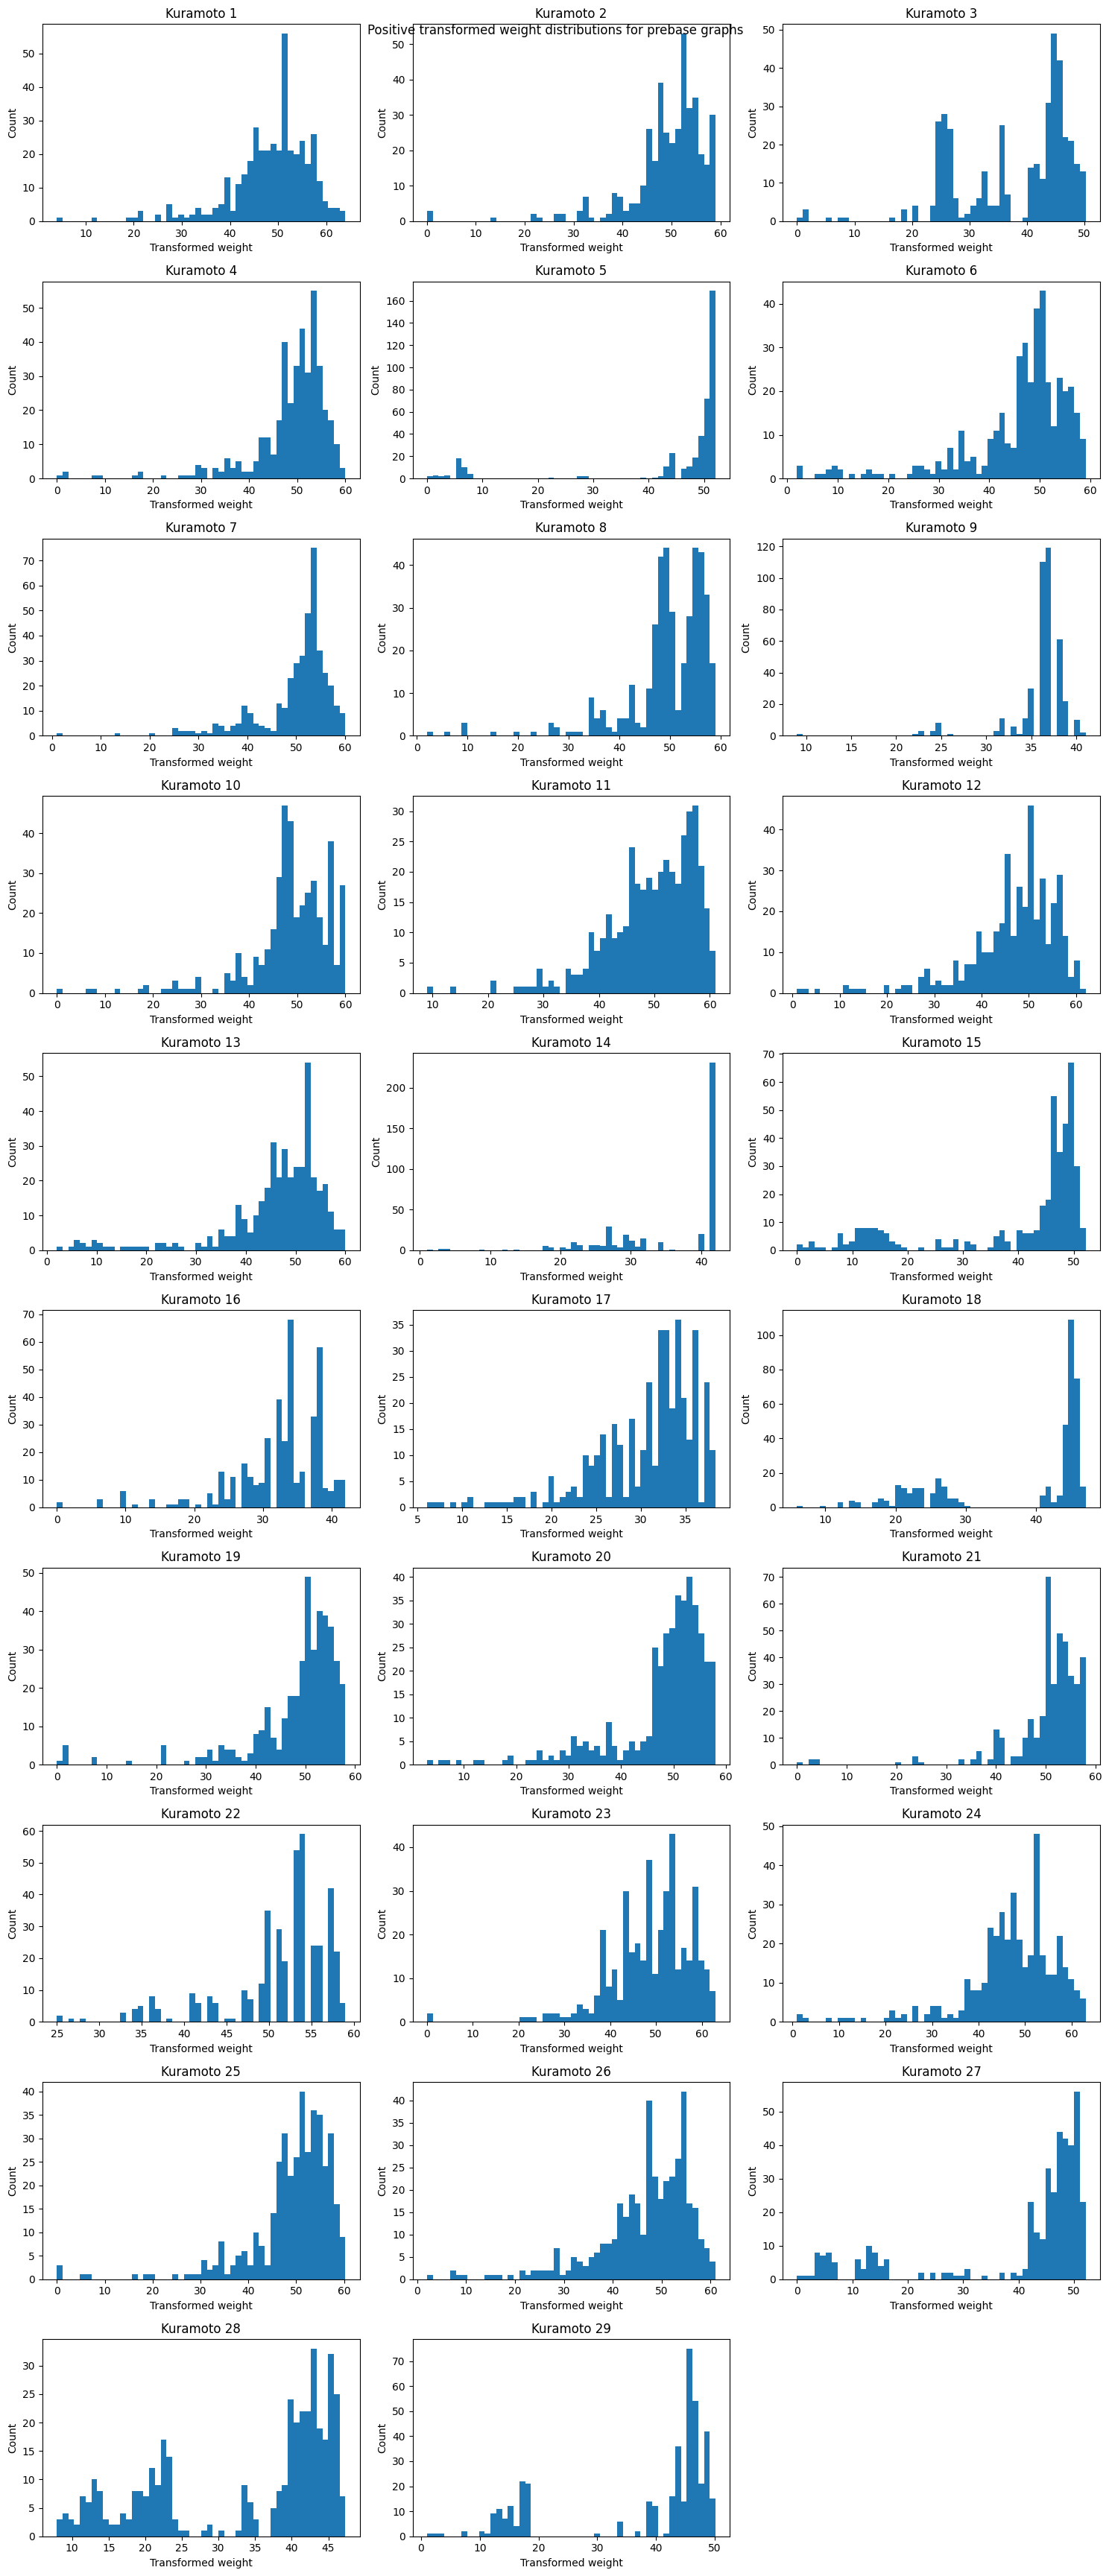

GDD(01, 02) = 5.772022109602424
GDD(01, 03) = 5.237532803595228
GDD(01, 04) = 5.73451366421726
GDD(01, 05) = 4.981486502001165
GDD(01, 06) = 5.4547086222653896
GDD(01, 07) = 5.1481465153933055
GDD(01, 08) = 4.4890119470420204
GDD(01, 09) = 4.519437507160895
GDD(01, 10) = 5.537234748619594
GDD(01, 11) = 5.171420476386196
GDD(01, 12) = 5.174960848176047
GDD(01, 13) = 5.5709134107694
GDD(01, 14) = 5.104417765198035
GDD(01, 15) = 4.89407306667477
GDD(01, 16) = 4.507249999335488
GDD(01, 17) = 5.113878748348362
GDD(01, 18) = 4.91801909853533
GDD(01, 19) = 5.473235724707274
GDD(01, 20) = 4.567162615776829
GDD(01, 21) = 4.776485612209703
GDD(01, 22) = 5.170545422856966
GDD(01, 23) = 5.171420476065127
GDD(01, 24) = 5.1758548747135125
GDD(01, 25) = 4.85002237175754
GDD(01, 26) = 5.628592244659771
GDD(01, 27) = 5.178217643253906
GDD(01, 28) = 5.011020071448094
GDD(01, 29) = 5.277823799915785
GDD(02, 03) = 5.0212127407493945
GDD(02, 04) = 5.45282799737127
GDD(02, 05) = 6.358547174309873
GDD(02, 06

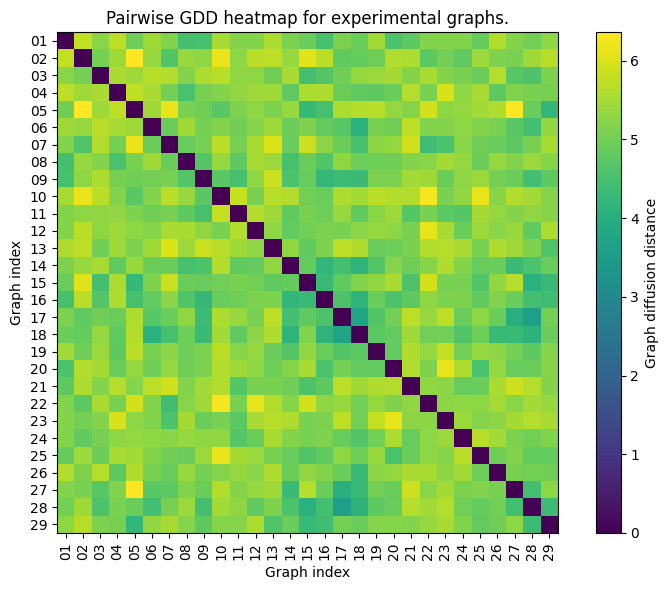

Full graph indices: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29']

Full global transform parameters:
sign: -1.0
scale: 1.0
shift: 2.000000001
raw_global_min: -62.0239483800847
raw_global_max: 2.0
signed_global_min: -2.0
signed_global_max: 62.0239483800847
transformed_global_min: 1.000000082740371e-09
transformed_global_max: 64.0239483810847


In [6]:
full_output = run_prebase_pipeline(
    indices=full_indices,
    base_dir=prebase_base_dir,
    suffix=prebase_suffix,
    weight_key=weight_key,
    symmetrize=symmetrize,
    frc_method=frc_method,
    transform_flip_sign=True,
    transform_rescale=None,
    weight_attr=weight_attr,
    show_weight_distributions=show_weight_distributions,
    bins=50,
    heatmap_figsize=(8, 6),
    heatmap_cmap="viridis",
    verbose=verbose,
)

if verbose:
    print("Full graph indices:", full_output["labels"])
    print("\nFull global transform parameters:")
    for key, value in full_output["global_linear_params"].items():
        print(f"{key}: {value}")
